In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, log_loss
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

In [3]:
#Dataset Load
df = pd.read_csv('sideout_clean.csv')
print(f"Rows: {len(df):,}, Sideout rate: {df['sideout'].mean():.1%}")

Rows: 82,663  |  Sideout rate: 56.6%


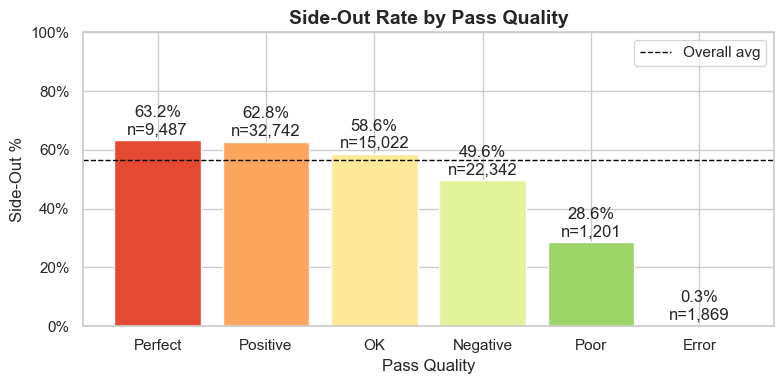

In [4]:
quality_order = ['Perfect', 'Positive', 'OK', 'Negative', 'Poor', 'Error']
pq = (df.groupby('pass_quality')['sideout']
        .agg(['mean', 'count'])
        .reindex(quality_order)
        .reset_index())
pq.columns = ['pass_quality', 'sideout_rate', 'n']
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(pq['pass_quality'], pq['sideout_rate'], color=sns.color_palette('RdYlGn', 6))
ax.axhline(df['sideout'].mean(), color='black', linestyle='--', linewidth=1, label='Overall avg')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 1)
ax.set_title('Side-Out Rate by Pass Quality', fontsize=14, fontweight='bold')
ax.set_xlabel('Pass Quality')
ax.set_ylabel('Side-Out %')
for bar, (_, row) in zip(bars, pq.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{row['sideout_rate']:.1%}\nn={row['n']:,}", ha='center', va='bottom')
ax.legend()
plt.tight_layout()
plt.show()

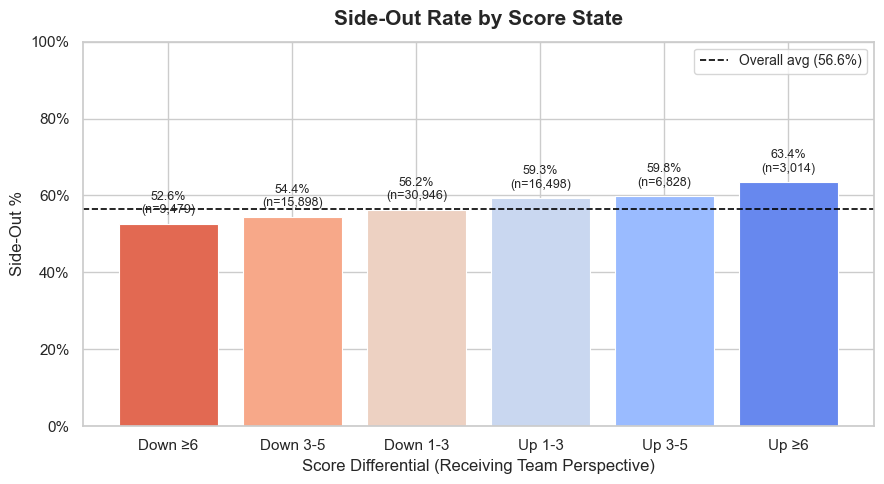

In [8]:
bins   = [-30, -6, -3, 0, 3, 6, 30]
labels = ['Down ≥6', 'Down 3-5', 'Down 1-3', 'Up 1-3', 'Up 3-5', 'Up ≥6']

df['score_bucket'] = pd.cut(df['score_diff'], bins=bins, labels=labels)

sc = (df.groupby('score_bucket', observed=True)['sideout']
        .agg(['mean', 'count'])
        .reset_index())
sc.columns = ['score_bucket', 'sideout_rate', 'n']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(sc['score_bucket'].astype(str), sc['sideout_rate'],
              color=sns.color_palette('coolwarm_r', len(sc)),
              edgecolor='white', linewidth=0.8)

ax.axhline(df['sideout'].mean(), color='black', linestyle='--',
           linewidth=1.2, label=f"Overall avg ({df['sideout'].mean():.1%})")

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 1)
ax.set_title('Side-Out Rate by Score State', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Score Differential (Receiving Team Perspective)', fontsize=12)
ax.set_ylabel('Side-Out %', fontsize=12)

for bar, (_, row) in zip(bars, sc.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{row['sideout_rate']:.1%}\n(n={row['n']:,})",
            ha='center', va='bottom', fontsize=9)

ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('sideout_by_score_state.png', dpi=150)
plt.show()

In [1]:
print(len(bins) - 1)
print(df['score_diff'].min(), df['score_diff'].max())
print(df['score_diff'].isna().sum())

NameError: name 'bins' is not defined

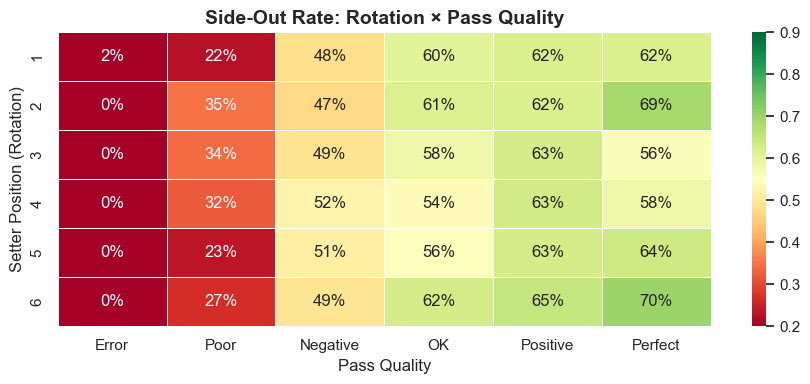

In [11]:
heat = (df.groupby(['receiving_setter_position', 'pass_quality'])['sideout']
          .mean()
          .unstack()
          .reindex(columns=quality_order))

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(heat, annot=True, fmt='.0%', cmap='RdYlGn',
            vmin=0.2, vmax=0.9, linewidths=0.5, ax=ax)
ax.set_title('Side-Out Rate: Rotation × Pass Quality', fontsize=14, fontweight='bold')
ax.set_xlabel('Pass Quality')
ax.set_ylabel('Setter Position (Rotation)')
plt.tight_layout()
plt.show()

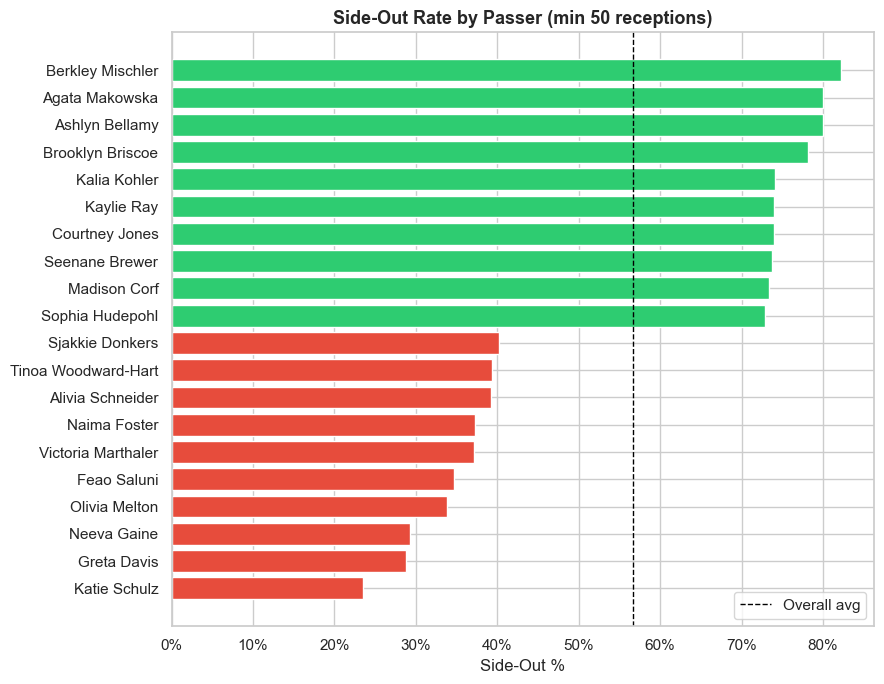

In [14]:
passer = (df.groupby(['player_id', 'player_name'])
            .agg(receptions=('sideout', 'count'),
                 sideout_rate=('sideout', 'mean'))
            .reset_index())

passer = passer[passer['receptions'] >= 50].sort_values('sideout_rate', ascending=False)

top_n = 20
plot_df = pd.concat([passer.head(top_n // 2), passer.tail(top_n // 2)])

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#2ecc71' if r >= df['sideout'].mean() else '#e74c3c'
          for r in plot_df['sideout_rate']]
ax.barh(plot_df['player_name'], plot_df['sideout_rate'], color=colors)
ax.axvline(df['sideout'].mean(), color='black', linestyle='--', linewidth=1, label='Overall avg')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Side-Out Rate by Passer (min 50 receptions)', fontsize=13, fontweight='bold')
ax.set_xlabel('Side-Out %')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# Encode pass quality as ordinal
quality_order = ['Error', 'Poor', 'Negative', 'OK', 'Positive', 'Perfect']
df['pass_quality_num'] = df['pass_quality'].map({q: i for i, q in enumerate(quality_order)})

features = ['pass_quality_num', 'receiving_setter_position', 'score_diff', 'set_number']
model_df = df[features + ['sideout']].dropna()

X = model_df[features]
y = model_df['sideout']

lr = LogisticRegression(max_iter=1000)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc   = cross_val_score(lr, X, y, cv=cv, scoring='roc_auc').mean()
logloss = -cross_val_score(lr, X, y, cv=cv, scoring='neg_log_loss').mean()

print("── Logistic Regression (5-fold CV) ──")
print(f"  AUC-ROC  : {auc:.4f}")
print(f"  Log Loss : {logloss:.4f}")
print(f"  Baseline (predict mean): {log_loss(y, [y.mean()] * len(y)):.4f}")

── Logistic Regression (5-fold CV) ──
  AUC-ROC  : 0.5971
  Log Loss : 0.6660
  Baseline (predict mean): 0.6844


── Random Forest (5-fold CV) ──
  AUC-ROC  : 0.6200
  Log Loss : 0.6505


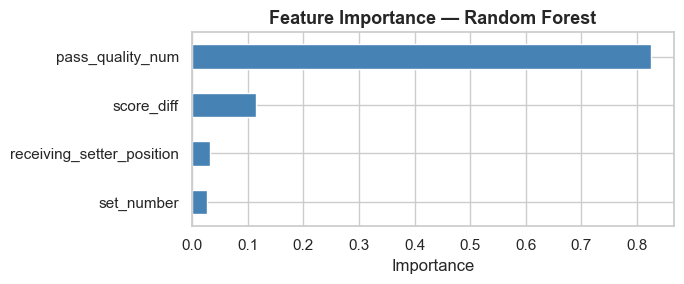

In [13]:
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)

auc_rf = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc').mean()
ll_rf  = -cross_val_score(rf, X, y, cv=cv, scoring='neg_log_loss').mean()

print("── Random Forest (5-fold CV) ──")
print(f"  AUC-ROC  : {auc_rf:.4f}")
print(f"  Log Loss : {ll_rf:.4f}")

# Fit once to get importances
rf.fit(X, y)
imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 3))
imp.plot.barh(ax=ax, color='steelblue')
ax.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

In [15]:
# Fit LR on full data to get expected probabilities per reception
lr_full = LogisticRegression(max_iter=1000)
model_df2 = df[features + ['sideout', 'player_id', 'player_name']].dropna()
X2 = model_df2[features]
y2 = model_df2['sideout']

lr_full.fit(X2, y2)
model_df2 = model_df2.copy()
model_df2['expected_sideout'] = lr_full.predict_proba(X2)[:, 1]

# Aggregate by player
player_summary = (model_df2.groupby(['player_id', 'player_name'])
                  .agg(receptions=('sideout', 'count'),
                       actual_rate=('sideout', 'mean'),
                       expected_rate=('expected_sideout', 'mean'))
                  .reset_index())

player_summary = player_summary[player_summary['receptions'] >= 50].copy()
player_summary['value_above_expected'] = player_summary['actual_rate'] - player_summary['expected_rate']
player_summary = player_summary.sort_values('value_above_expected', ascending=False)

print(player_summary[['player_name','receptions','actual_rate','expected_rate','value_above_expected']]
      .round(3).to_string(index=False))

            player_name  receptions  actual_rate  expected_rate  value_above_expected
       Berkley Mischler          56        0.821          0.594                 0.228
         Ashlyn Bellamy          70        0.800          0.574                 0.226
         Agata Makowska          50        0.800          0.599                 0.201
       Brooklyn Briscoe          55        0.782          0.583                 0.199
             Kaylie Ray          50        0.740          0.552                 0.188
         Seenane Brewer          57        0.737          0.553                 0.183
         Courtney Jones          73        0.740          0.561                 0.178
           Kalia Kohler          54        0.741          0.575                 0.166
         Maria Tabacuks          53        0.717          0.554                 0.163
           Madison Corf          60        0.733          0.572                 0.161
        Sophia Hudepohl         162        0.728      

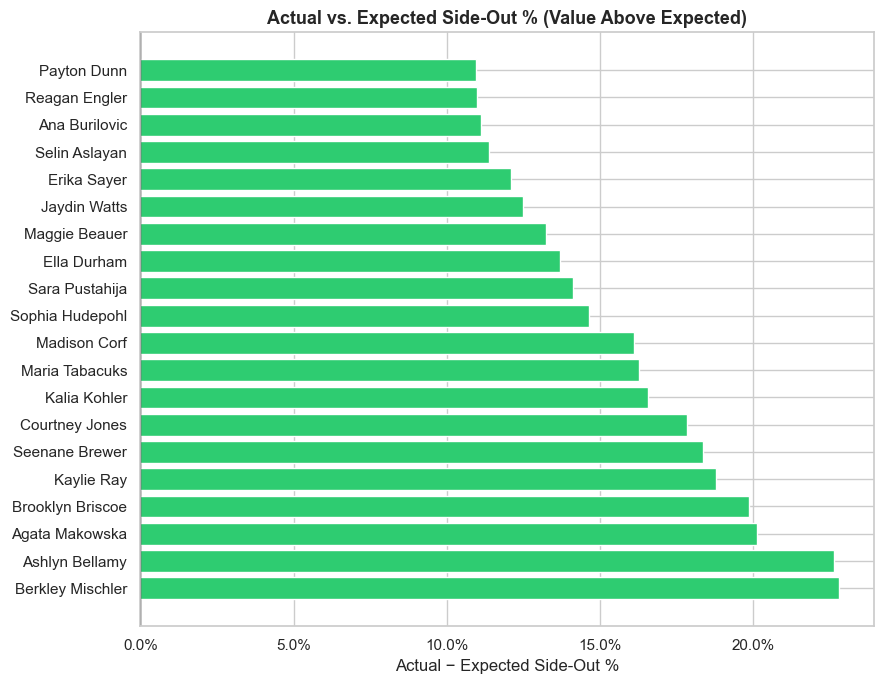

In [16]:
plot = player_summary.head(20).sort_values('value_above_expected')

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in plot['value_above_expected']]
ax.barh(plot['player_name'], plot['value_above_expected'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Actual vs. Expected Side-Out % (Value Above Expected)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Actual − Expected Side-Out %')
ax.invert_yaxis()
plt.tight_layout()
plt.show()